In [1]:
import numpy as np
import scipy as sp
from scipy.sparse import diags as spMtrx


import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe


import seaborn as sns

# Gloabal Variables 

## Plotting

In [2]:
clrmap =sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)
clrlin = clrmap 

fntsize = [8,  # contour line numbers
           10, # Sub axies
           12, # Main axies
           18, # Normal Titles
           24] # Sup Title for combined Figures
figSize1 = (10,8)

## Numerical

In [3]:
################# Grid Info #################
Nx = 60
Ny = 60
L  = 1
ix = np.linspace(1, Nx, Nx)  
iy = np.linspace(1, Ny, Ny)

x      = ix/(Nx+1)
y      = iy/(Ny+1)
dx     = x[1] - x[0]
dy     = y[1] - y[0]
[Y, X] = np.meshgrid(y, x) 

################# Functions #################
a = 0.005

k      = 0.02 * np.exp(-((X-0.7)**2/0.09 + (Y-0.6)**2/0.25))
k_flat = k.reshape(-1, order='F')

# boundary conditions
BCL_D = 0.5 - 0.5 * np.cos(2 * np.pi * y)
BCR_N = np.zeros(len(y))
BCB_N = -0.3 * np.ones(len(x))
BCT_D = 0.5 + 0.5 * np.sin(4*np.pi * x - 0.5*np.pi)

################# Solvers #################

index = np.arange(0, Nx * Ny).reshape((Nx, Ny), order='F')

tol   = 1e-4
maxit = 5000
dt    = 0.1

x0 = np.reshape(k,(Nx*Ny))#np.zeros(Nx * Ny)

## Checking $\kappa(xy)$

Text(0, 0.5, '$Y$')

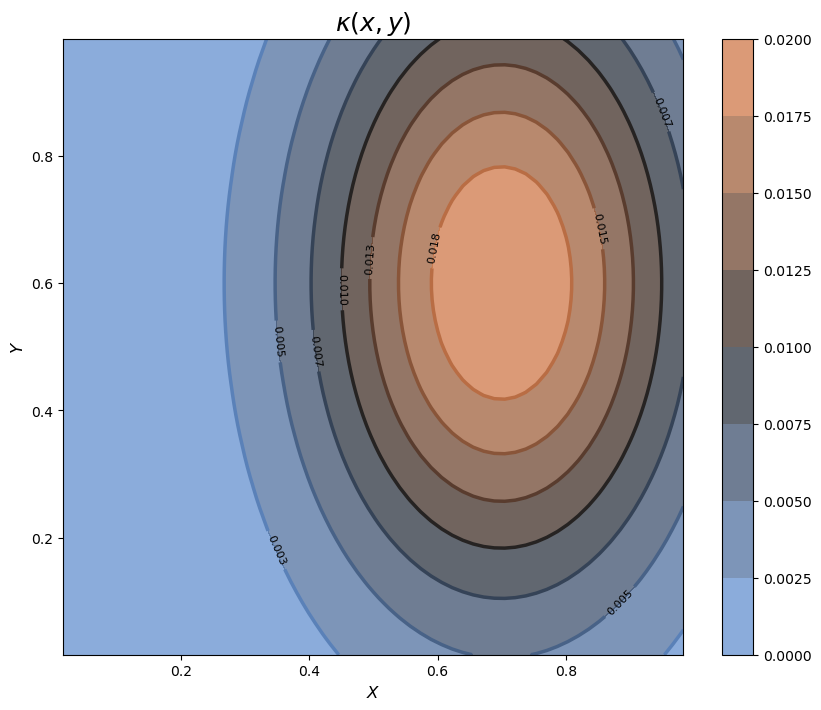

In [4]:
fig = plt.figure(figsize=figSize1)

plt.contourf(X, Y, k, levels=8, cmap=clrmap, alpha = 0.75)
plt.colorbar()

c = plt.contour(X, Y, k, levels=8, cmap=clrlin, linewidths=2.5)
clabels = plt.clabel(c, inline=True, fontsize=fntsize[0], colors='black', fmt='%.3f')

plt.title(r'$\kappa(x,y)$',fontsize=fntsize[-2])
plt.xlabel(r'$X$',fontsize=fntsize[-3])
plt.ylabel(r'$Y$',fontsize=fntsize[-3])

# plt.savefig(f'../../project_1/figs/contour_kappa_{Nx}x{Ny}.png', dpi=300)

## Functions

In [5]:
def Laplace_u(u, Nx, Ny, index, dx, dy):
    value = np.zeros_like(u)
    # internal nodes
    for j in range(1, Ny-1):
        for i in range(1, Nx-1):
            idx = index[i, j]
            value[idx] = (u[index[i+1, j]] - 2*u[idx] + u[index[i-1, j]]) / dx**2 + \
                         (u[index[i, j+1]] - 2*u[idx] + u[index[i, j-1]]) / dy**2
    # west boundary (dirichlet)
    i = 0
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = (-2*u[idx] + u[index[i+1, j]]) / dx**2 + \
                      + (u[index[i, j+1]] - 2*u[idx] + u[index[i, j-1]]) / dy**2
    # east boundary (neumann)
    i = Nx-1
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = (u[index[i-1, j]] - u[idx]) / dx**2 + \
                      + (u[index[i, j+1]] - 2*u[idx] + u[index[i, j-1]]) / dy**2
    # north boundary (dirichlet)
    j = Ny-1  
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = (u[index[i+1, j]] - 2*u[idx] + u[index[i-1, j]]) / dx**2 + \
                      + (-2*u[idx] + u[index[i, j-1]]) / dy**2
    # south boundary (neumann)
    j = 0
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = (u[index[i+1, j]] - 2*u[idx] + u[index[i-1, j]]) / dx**2 + \
                      + (u[index[i, j+1]] - u[idx]) / dy**2
    # corners
    # southwest corner (west dirichlet + south neumann)
    i, j = 0, 0
    idx = index[i, j]
    value[idx] = (-2*u[idx] + u[index[i+1, j]]) / dx**2 + \
                  + (u[index[i, j+1]] - u[idx]) / dy**2
    # southeast corner (east neumann + south neumann)
    i, j = Nx-1, 0
    idx = index[i, j]
    value[idx] = (u[index[i-1, j]] - u[idx]) / dx**2 + \
                  + (u[index[i, j+1]] - u[idx]) / dy**2
    # northwest corner (west dirichlet + north dirichlet)
    i, j = 0, Ny-1
    idx = index[i, j]
    value[idx] = (-2*u[idx] + u[index[i+1, j]]) / dx**2 + \
                  + (-2*u[idx] + u[index[i, j-1]]) / dy**2
    # northeast corner (east neumann + north dirichlet)
    i, j = Nx-1, Ny-1
    idx = index[i, j]
    value[idx] = (u[index[i-1, j]] - u[idx]) / dx**2 + \
                  + (-2*u[idx] + u[index[i, j-1]]) / dy**2
    return value

In [6]:
def Laplace_BC(Nx, Ny, index, dx, dy, BCL_D, BCR_N, BCB_N, BCT_D):
    value = np.zeros(Nx*Ny)

    # west boundary (dirichlet)
    i = 0
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = BCL_D[j] / dx**2

    # east boundary (neumann)
    i = Nx-1
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = BCR_N[j] / dx  

    # north boundary (dirichlet)
    j = Ny-1
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = BCT_D[i] / dy**2

    # south boundary (neumann)
    j = 0
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = -BCB_N[i] / dy  

    # corners
    # southwest corner (west dirichlet + south neumann)
    i, j = 0, 0
    idx = index[i, j]
    value[idx] = BCL_D[j] / dx**2 - BCB_N[i] / dy

    # southeast corner (east neumann + south neumann)
    i, j = Nx-1, 0
    idx = index[i, j]
    value[idx] = BCR_N[j] / dx - BCB_N[i] / dy 

    # northwest corner (west dirichlet + north dirichlet)
    i, j = 0, Ny-1
    idx = index[i, j]
    value[idx] = BCL_D[j] / dx**2 + BCT_D[i] / dy**2

    # northeast corner (east neumann + north dirichlet)
    i, j = Nx-1, Ny-1
    idx = index[i, j]
    value[idx] = BCR_N[j] / dx + BCT_D[i] / dy**2 

    return value

In [7]:
LHS = lambda u: -a * Laplace_u(u, Nx, Ny, index, dx, dy)

LBC = Laplace_BC(Nx, Ny, index, dx, dy, BCL_D, BCR_N, BCB_N, BCT_D)

RHS = k_flat + a*LBC

In [8]:
def cg_solver(LHS, RHS, x0, tol, maxit):
    u = x0.copy()
    r = RHS - LHS(u)
    p = r.copy()
    res0 = np.linalg.norm(r)
    # resvec = np.zeros(maxit)
    
    # Storage: list of (iteration, solution_2D,norm) tuples
    # Storage: list of (time, solution_2D,norm) tuples
    history = {'step':[],
               'field':[],
               'rezg':[]}


    for step in range(1, maxit + 1):
        LHS_p = LHS(p)
        alpha = (r @ r) / (p @ LHS_p)

        r_new = r - alpha * LHS_p

        resvec = np.linalg.norm(r_new) / res0
        
        history['step'].append(step)
        history['field'].append(u)
        history['rezg'].append(resvec)
        
        if resvec < tol:
            history['step'].append(step)
            history['field'].append(u)
            history['rezg'].append(resvec)
            return history

        u = u + alpha * p
        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new

    return history

# Poisson Steady State Soln

In [9]:
# Storage: list of (iteration, solution_2D, norm) tuples
cg_soln = cg_solver(LHS, RHS, x0, tol, maxit)
print('CG converged in', cg_soln['step'][-1], '\niterations with final residual', cg_soln['rezg'][-1])

CG converged in 160 
iterations with final residual 9.30435381952579e-05


In [10]:
U_ss = cg_soln['field'][-1].reshape(Nx, Ny).T

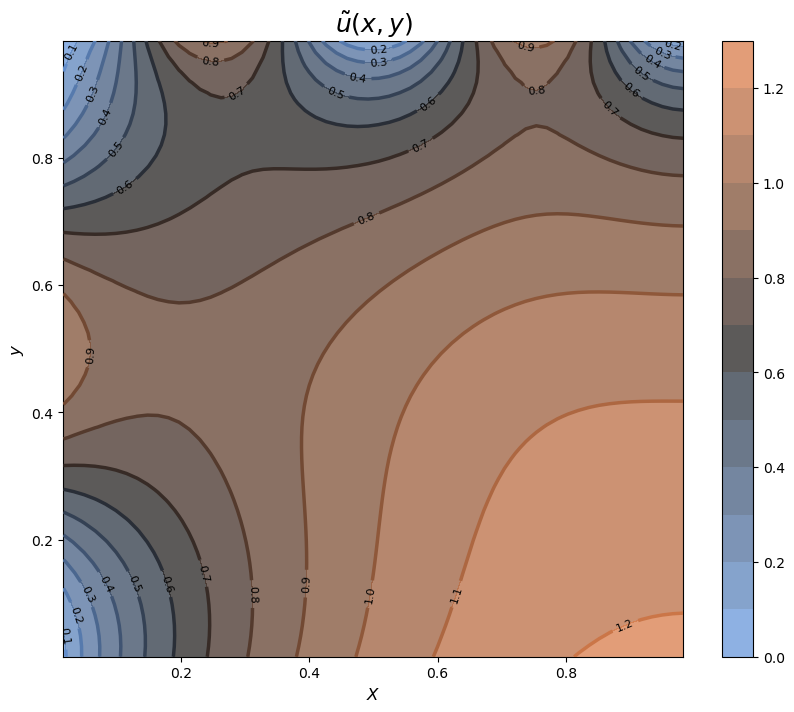

In [11]:
fig = plt.figure(figsize=figSize1)

levs = 12
cf = plt.contourf(X, Y, U_ss, levels=levs, cmap=clrmap, alpha=0.75, zorder=1)
plt.colorbar(cf)
# Contour lines colored by the colormap, drawn on top
c = plt.contour(X, Y, U_ss, levels=levs, cmap=clrlin, linewidths=2.5, zorder=5)
# Labels drawn on top of everything
plt.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
plt.title(r'$\tilde{u}(x,y)$',fontsize=fntsize[-2])
plt.xlabel(r'$X$',fontsize=fntsize[-3])
plt.ylabel(r'$y$',fontsize=fntsize[-3])

# Save figure
# plt.savefig(f'../../project_1/figs/poissonSS_{Nx}x{Ny}.png', dpi=300)
plt.show()

# Simulation

In [12]:
# Crank-Nicolson for transient heat equation
alpha = a
A_CN = lambda u: u - (alpha * dt / 2) * Laplace_u(u, Nx, Ny, index, dx, dy)
uT = k_flat.copy()
L_BC = Laplace_BC(Nx, Ny, index, dx, dy, BCL_D, BCR_N, BCB_N, BCT_D)
U_ss_vector = U_ss.reshape(-1, order='F')

maxit_Heat = 5000
maxit_CG = 5000
time_stop = None

# Storage: list of (time, solution_2D,norm) tuples
sim_soln = {'time':[],
           'field':[],
           'norm':[]}
           
    
for it in range(1, maxit_Heat + 1):

    L_int = Laplace_u(uT, Nx, Ny, index, dx, dy)
    RHS = alpha * dt / 2 * (L_int + 2 * L_BC) + dt * k_flat + uT
    temp = cg_solver(A_CN, RHS, uT, tol, maxit_CG)
    
    it_cg  = temp['step'][-1]
    uT     = temp['field'][-1]
    res_cg = temp['rezg'][-1]
    
    norm = np.linalg.norm(uT - U_ss_vector, 2) / np.linalg.norm(U_ss_vector, 2)
    
    sim_soln['time'].append(it * dt)
    sim_soln['field'].append(uT.reshape(Nx, Ny, order='F'))
    sim_soln['norm'].append(norm)
    

    print(f'iterations: {it}', end='\r')

    if norm < 1e-4:
        time_stop = it * dt
        print(f'Converged at t = {time_stop:.4f} ({it} timesteps)')
        break

if time_stop is None:
    print('Did not converge within maximum iterations')

Converged at t = 371.3000 (3713 timesteps)


In [13]:
steps = np.array([0, 50, 150, 300, 600, 1000, 2500, -1],dtype=int)  

# labels = [r'$t=$' + f'{history[0][0]:.0f}'+r'$[s]$, $\kappa{{(x,y)}}$'] + \
#           [f't = {history[s][0]:.0f} $[s]$' for s in steps[1:-1]] + \
#          [fr'$t = {history[-1][0]:.0f}$[s]$,\ \tilde{{u}}$']


labels = [sim_soln['time'][s] for s in steps]
          
# Compute global min/max for consistent colorbar
vmin = min(sim_soln['field'][s].min() for s in steps)
vmax = max(sim_soln['field'][s].max() for s in steps)

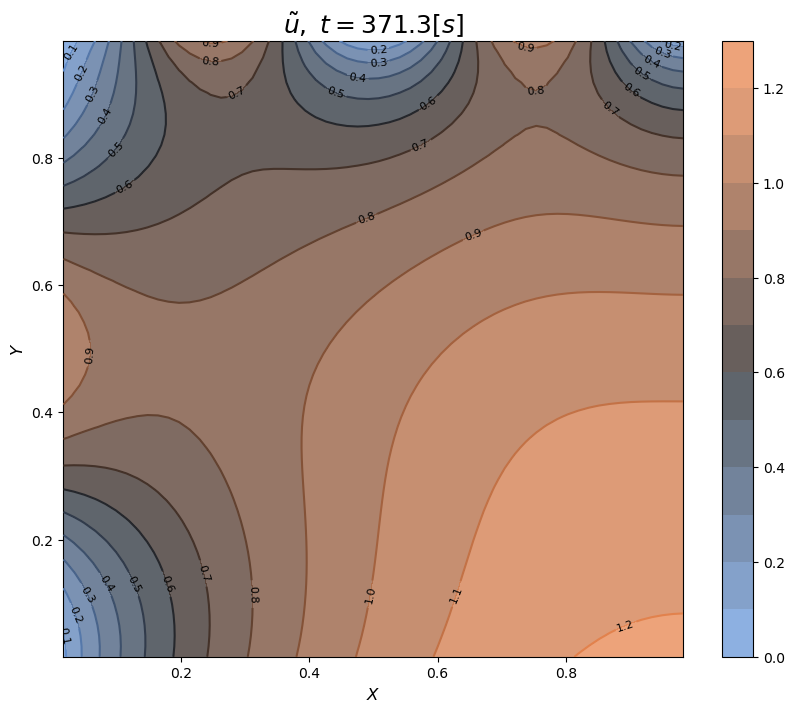

In [14]:
fig = plt.figure(figsize=figSize1)

step = steps[-1]
U_plt = sim_soln['field'][step]
label = labels[step]

cf = plt.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = plt.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
plt.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
plt.title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-2])
plt.xlabel(r'$X$',fontsize=fntsize[-3])
plt.ylabel(r'$Y$',fontsize=fntsize[-3])

plt.colorbar(cf)

# plt.savefig(f'../../project_1/figs/simSS_{Nx}x{Ny}.png',dpi=300)

plt.show()

## Grid Display

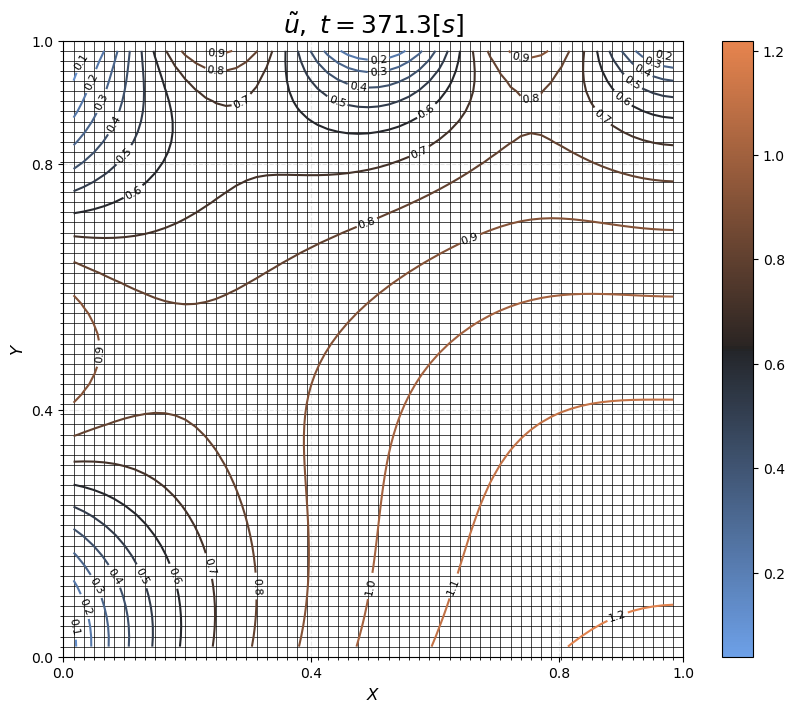

In [15]:
fig, ax = plt.subplots(figsize=figSize1)

step = steps[-1]
U_plt = sim_soln['field'][step]
label = labels[step]

# cf = plt.contourf(X, Y, U_plot, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = ax.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
ax.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')

ax.set_xticks([0, 0.4, 0.8, 1])
ax.set_yticks([0, 0.4, 0.8, 1])

ax.set_xticks(x, minor=True)
ax.set_yticks(y, minor=True)


# plt.sxticklabels([])
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.grid(which='major', linestyle='--', alpha=0.3)


# ax.tick_params(axis='x', which='both', bottom=False,top=False,labelbottom=False)
# ax.xticks([])
ax.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-2])
ax.set_xlabel(r'$X$',fontsize=fntsize[-3])
ax.set_ylabel(r'$Y$',fontsize=fntsize[-3])



norm = mcolors.Normalize(vmin=U_plt.min(), vmax=U_plt.max())
sm = plt.cm.ScalarMappable(cmap=clrmap, norm=norm)
sm.set_array([])  # required for colorbar

# ---- colorbar ----
fig.colorbar(sm, ax=ax)

# plt.savefig(f'../../project_1/figs/simSS_grid__{Nx}x{Ny}.png',dpi=300)
plt.show()

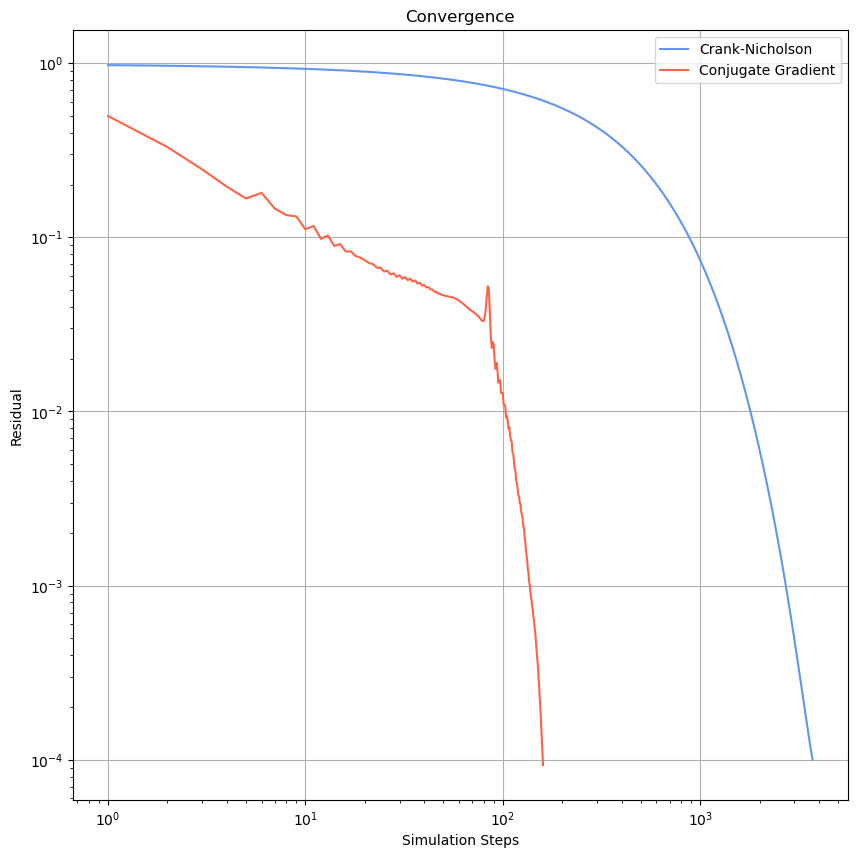

In [16]:
simSteps = np.array(sim_soln['time'])/dt 
simNorm = sim_soln['norm']

cgSteps = cg_soln['step']
cgNorm = cg_soln['rezg']

fig = plt.figure(figsize=(10,10))

plt.loglog(simSteps,simNorm,color='cornflowerblue',label='Crank-Nicholson')
plt.loglog(cgSteps,cgNorm,color='tomato', label='Conjugate Gradient')
plt.grid()
plt.xlabel('Simulation Steps')
plt.ylabel('Residual')
plt.title('Convergence')
plt.legend()

# plt.savefig('../../project_1/figs/convergence.png',dpi=300)

plt.show()

In [17]:
step

-1

## Display simulation steps

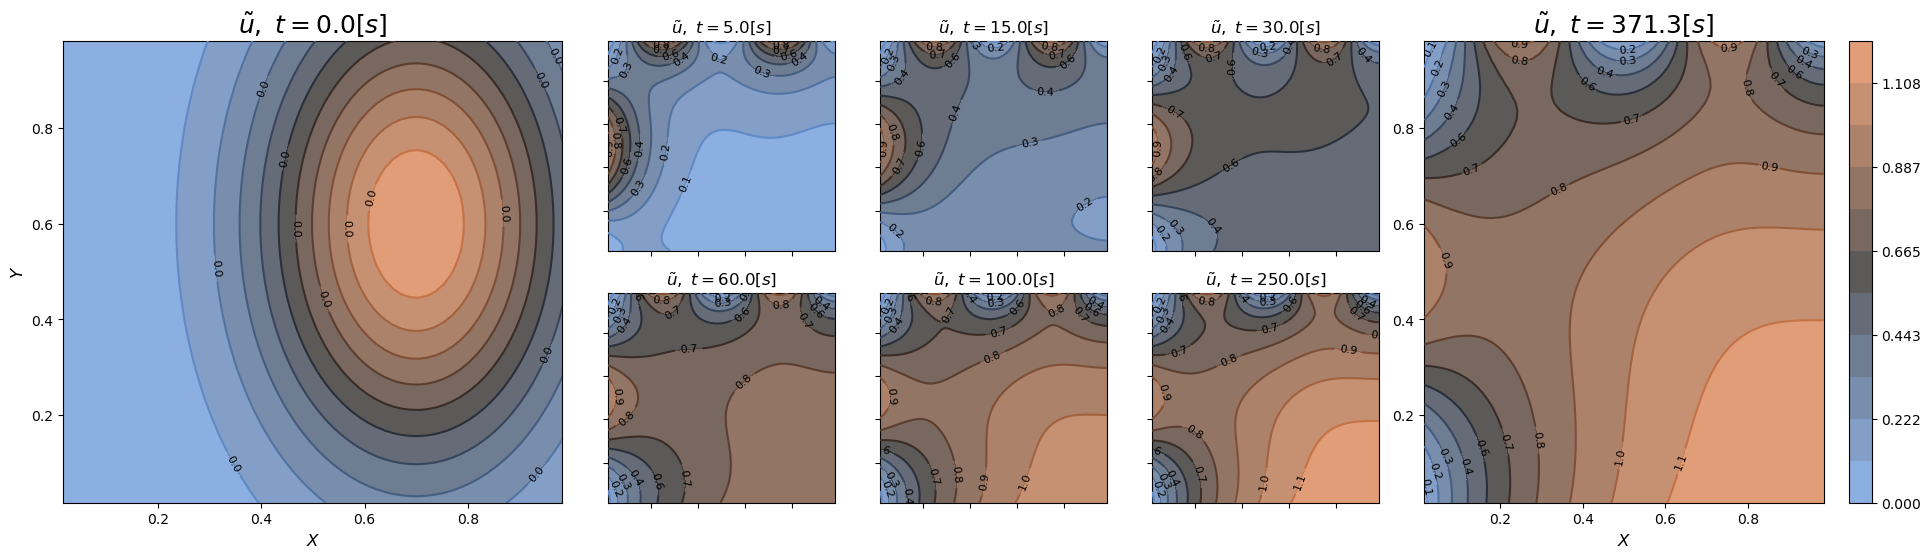

In [18]:
levs = np.linspace(vmin, vmax, 12)
lev0 = np.linspace(0, np.max(k), 12)


fig = plt.figure(figsize=(24,6))
gs = gridspec.GridSpec(2,7,width_ratios=[1,1,1,1,1,1,1])


pIn = fig.add_subplot(gs[:,:2])

p1 = fig.add_subplot(gs[0,2])
p2 = fig.add_subplot(gs[0,3])
p3 = fig.add_subplot(gs[0,4])
p4 = fig.add_subplot(gs[1,2])
p5 = fig.add_subplot(gs[1,3])
p6 = fig.add_subplot(gs[1,4])

pSS = fig.add_subplot(gs[:,-2:])


###################################
############ Plot Input ###########

step = steps[0]
U_plt = k#sim_soln['field'][step]
label = np.round(sim_soln['time'][step],0)#labels[step]

lev0 = np.linspace(0, np.max(U_plt), 12)

cf = pIn.contourf(X, Y, U_plt, levels=lev0, cmap=clrmap, alpha=0.75, vmin=0, vmax=k.max(), zorder=1)
c  = pIn.contour( X, Y, U_plt, levels=lev0, cmap=clrlin, linewidths=1.5, vmin=0, vmax=k.max(), zorder=5)
pIn.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
pIn.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-2])
pIn.set_xlabel(r'$X$',fontsize=fntsize[-3])
pIn.set_ylabel(r'$Y$',fontsize=fntsize[-3])


###################################
############ Plot Steps ###########

step = steps[1]
U_plt = sim_soln['field'][step]
label = np.round(sim_soln['time'][step],0)

cf = p1.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = p1.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
p1.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
p1.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-3])
# p1.set_xlabel(r'$X$')
# p1.set_ylabel(r'$Y$')
p1.set_yticklabels([])
p1.set_xticklabels([])

#------------------------------------

step = steps[2]
U_plt = sim_soln['field'][step]
label = np.round(sim_soln['time'][step],0)

cf = p2.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = p2.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
p2.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
p2.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-3])
# p2.set_xlabel(r'$X$')
# p2.set_ylabel(r'$Y$')
p2.set_yticklabels([])
p2.set_xticklabels([])

#------------------------------------

step = steps[3]
U_plt = sim_soln['field'][step]
label = np.round(sim_soln['time'][step],0)

cf = p3.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = p3.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
p3.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
p3.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-3])
# p3.set_xlabel(r'$X$')
# p3.set_ylabel(r'$Y$')
p3.set_yticklabels([])
p3.set_xticklabels([])


#------------------------------------

step = steps[4]
U_plt = sim_soln['field'][step]
label = np.round(sim_soln['time'][step],0)

cf = p4.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = p4.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
p4.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
p4.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-3])
# p4.set_xlabel(r'$X$')
# p4.set_ylabel(r'$Y$')
p4.set_yticklabels([])
p4.set_xticklabels([])

#------------------------------------

step = steps[5]
U_plt = sim_soln['field'][step]
label = np.round(sim_soln['time'][step],0)

cf = p5.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = p5.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
p5.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
p5.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-3])
# p5.set_xlabel(r'$X$')
# p5.set_ylabel(r'$Y$')
p5.set_yticklabels([])
p5.set_xticklabels([])

#------------------------------------

step = steps[6]
U_plt = sim_soln['field'][step]
label = np.round(sim_soln['time'][step],0)

cf = p6.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = p6.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
p6.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
p6.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-3])
# p6.set_xlabel(r'$X$')
# p6.set_ylabel(r'$Y$')
p6.set_yticklabels([])
p6.set_xticklabels([])




###################################
############ Plot Input ###########

step = steps[-1]
U_plt = sim_soln['field'][step]
label = np.round(sim_soln['time'][step],1)

cf = pSS.contourf(X, Y, U_plt, levels=levs, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
c  = pSS.contour( X, Y, U_plt, levels=levs, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
pSS.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', zorder=10, colors='black')
pSS.set_title(fr'$\tilde{{u}},\ t={label}[s]$', fontsize=fntsize[-2])
pSS.set_xlabel(r'$X$',fontsize=fntsize[-3])
# pSS.set_ylabel(r'$Y$',fontsize=fntsize[-3])
# pSS.yaxis.tick_right()
# pSS.yaxis.set_label_position("right")
plt.colorbar(cf)



# plt.savefig(f'../../project_1/figs/simSteps_{Nx}x{Ny}.png', dpi=300, bbox_inches='tight')
plt.show()

## Animation

In [19]:
import matplotlib.animation as animation

vmin = min(h[1].min() for h in sim_soln)
vmax = max(h[1].max() for h in sim_soln)
levels = np.linspace(vmin, vmax, 12)

fig, ax = plt.subplots(figsize=figSize1)

# Draw initial frame
cf = ax.contourf(X, Y, sim_soln['field'][0], levels=levels, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax)
c  = ax.contour( X, Y, sim_soln['field'][0], levels=levels, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax)
ax.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', colors='black')
# title = ax.set_title(f't = {history[0][0]:.2f}', fontsize=fntsize[-2])
ax.set_xlabel(r'$X$',fontsize=fntsize[-3])
ax.set_ylabel(r'$Y$',fontsize=fntsize[-3])

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=clrmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, ax=ax, label=r'$u(x,y,t)$')

def update(frame):
    ax.cla()  # clear axes for redraw
    U_plt = sim_soln['field'][frame]
    cf = ax.contourf(X, Y, U_plt, levels=levels, cmap=clrmap, alpha=0.75, vmin=vmin, vmax=vmax)
    c  = ax.contour( X, Y, U_plt, levels=levels, cmap=clrlin, linewidths=1.5, vmin=vmin, vmax=vmax)
    ax.clabel(c, inline=True, fontsize=fntsize[0], fmt='%0.1f', colors='black')
    ax.set_title(f't = {t_val:.2f}', fontsize=fntsize[-2])
    ax.set_xlabel(r'$X$',fontsize=fntsize[-3])
    ax.set_ylabel(r'$Y$',fontsize=fntsize[-3])

# ani = animation.FuncAnimation(fig, update, frames=range(0, len(sim_soln), 10), interval=100, repeat=True)
# Save as gif
# ani.save(f'../../project_1/figs/simAnimation_{Nx}x{Ny}.gif', writer='pillow', dpi=150)
print('Animation saved!')

AttributeError: 'str' object has no attribute 'min'